### Analysis of Probability Distribution Priors from ResStock

Library Imports

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats


Configurations

In [25]:
resstock_dir = "/jumbo/keller-lab/Jeremy_Wang/resstock"
housing_characteristics_dir = os.path.join(resstock_dir, "project_national", "housing_characteristics")
options_dir = os.path.join(resstock_dir, "resources", "options_lookup.tsv")

Reading Options File

In [26]:
# Read all lines manually, pad short rows with NaN
with open(options_dir, 'r') as f:
    lines = [line.strip().split('\t') for line in f]

header = lines[0]
max_cols = max(len(row) for row in lines[1:])

# Pad header if it's shorter than some rows
while len(header) < max_cols:
    header.append(f'col_{len(header)}')

# Pad each row with None (becomes NaN in DataFrame)
padded = [row + [None] * (max_cols - len(row)) for row in lines[1:]]

options = pd.DataFrame(padded, columns=header)

#### Heating setpoint 

In [128]:
# reading heating_setpoint file
heating_setpoint = pd.read_csv(os.path.join(housing_characteristics_dir, 'Heating Setpoint.tsv'), sep='\t')

# skeleton IDF constraints
climate_zone = "5A" # chicago 
building_type = "Single-Family Detached" 
HVAC_heating_type = "Ducted Heat Pump"

# filter by constraints
mask = (
    (heating_setpoint['Dependency=ASHRAE IECC Climate Zone 2004'] == climate_zone) &
    (heating_setpoint['Dependency=Geometry Building Type RECS'] == building_type) &
    (heating_setpoint['Dependency=HVAC Heating Type'] == HVAC_heating_type) &
    (heating_setpoint['Dependency=HVAC Has Zonal Electric Heating'] == 'No')
    )

heating_filtered = heating_setpoint[mask]

# delete misinputted dataset
heating_filtered = heating_filtered[heating_filtered['Dependency=Tenure'] != 'Not Available']

# Get option columns
opt_cols = [c for c in heating_filtered.columns if c.startswith('Option=')]

# Weight by source_weight
heating_weights = heating_filtered['source_weight'].values
heating_weights = heating_weights / heating_weights.sum()

# Weighted average across tenure types
heating_weighted_probs = pd.Series(
    np.average(heating_filtered[opt_cols].values, axis=0, weights=heating_weights),
    index=opt_cols
)

### convert setpoints from fahrenheit to celsius
# Convert option names from F to C
def f_to_c(f):
    return (f - 32) * 5/9

# Extract numeric F values from option names
heating_f_values = np.array([float(c.replace('Option=', '').replace('F', '')) 
                     for c in opt_cols])

# Convert to Celsius
heating_c_values = f_to_c(heating_f_values)

#### Cooling Setpoint

In [129]:
# reading cooling_setpoint file
cooling_setpoint = pd.read_csv(os.path.join(housing_characteristics_dir, 'Cooling Setpoint.tsv'), sep='\t')

# skeleton IDF constraints
climate_zone = "5A" # chicago 
building_type = "Single-Family Detached" 
HVAC_cooling_type = "Ducted Heat Pump"

# filter by constraints
mask = (
    (cooling_setpoint['Dependency=ASHRAE IECC Climate Zone 2004'] == climate_zone) &
    (cooling_setpoint['Dependency=Geometry Building Type RECS'] == building_type) &
    (cooling_setpoint['Dependency=HVAC Cooling Type'] == HVAC_cooling_type)
    )
cooling_filtered = cooling_setpoint[mask]
cooling_filtered = cooling_filtered[cooling_filtered['Dependency=Tenure'] != 'Not Available']
cooling_filtered = cooling_filtered.drop(columns=['Option=Void'], errors='ignore')

# Get option columns
opt_cols = [c for c in cooling_filtered.columns if c.startswith('Option=')]

# Weight by source_weight
cooling_weights = cooling_filtered['source_weight'].values
cooling_weights = cooling_weights / cooling_weights.sum()
# Weighted average across tenure types
cooling_weighted_probs = pd.Series(
    np.average(cooling_filtered[opt_cols].values, axis=0, weights=cooling_weights),
    index=opt_cols
)

### convert setpoints from fahrenheit to celsius
# Convert option names from F to C
def f_to_c(f):
    return (f - 32) * 5/9

# Extract numeric F values from option names
cooling_f_values = np.array([float(c.replace('Option=', '').replace('F', '')) 
                     for c in opt_cols])

# Convert to Celsius
cooling_c_values = f_to_c(cooling_f_values)

### plots

Weighted mean: 20.80C
Weighted std:  1.52C


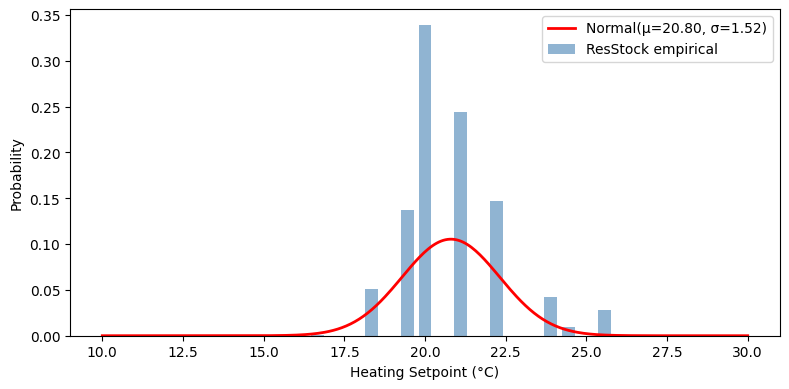


Concrete prior: Normal(mean=20.80, std=1.52)
Weighted mean: 22.18C
Weighted std:  1.97C


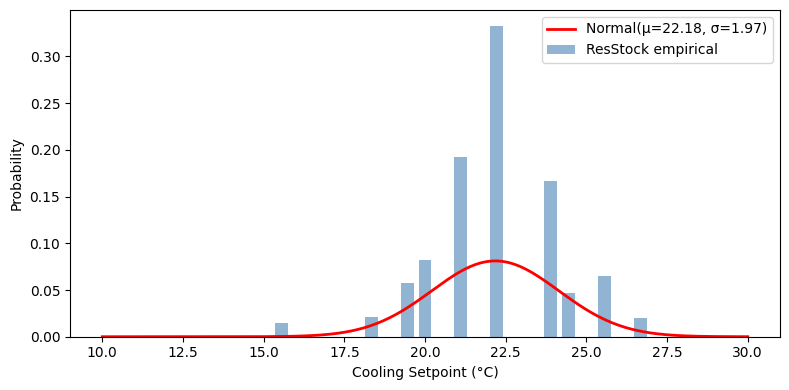


Concrete prior: Normal(mean=22.18, std=1.97)


In [130]:

# Compute weighted mean and std directly from the distribution
def plot_setpoint_prior (c_values, weighted_probs, title):
        mean_c = np.average(c_values, weights=weighted_probs.values)
        std_c = np.sqrt(np.average((c_values - mean_c)**2, weights=weighted_probs.values))

        print(f"Weighted mean: {mean_c:.2f}C")
        print(f"Weighted std:  {std_c:.2f}C")

        x = np.linspace(10, 30, 300)
        normal_pdf = stats.norm.pdf(x, loc=mean_c, scale=std_c)

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(c_values, weighted_probs.values, width=0.4, alpha=0.6,
        label='ResStock empirical', color='steelblue')
        ax.plot(x, normal_pdf * 0.4, 'r-', lw=2,
                label=f'Normal(μ={mean_c:.2f}, σ={std_c:.2f})')
        ax.set_xlabel(f'{title} (°C)')
        ax.set_ylabel('Probability')
        ax.legend()
        plt.tight_layout()
        plt.savefig('heating_setpoint_prior.png', dpi=150)
        plt.show()

        print(f"\nConcrete prior: Normal(mean={mean_c:.2f}, std={std_c:.2f})")

plot_setpoint_prior(heating_c_values, heating_weighted_probs, "Heating Setpoint")
plot_setpoint_prior(cooling_c_values, cooling_weighted_probs, "Cooling Setpoint")